### ＡIプログラミング2 7,8回目<br>

# 2. 手書き文字認識をニューラルネットワークで実行

## データを訓練(学習)用とテスト用に分割する

In [1]:
import torch
import matplotlib.pyplot as plt

#skit learnのモジュールを読み込む
from sklearn import datasets
from sklearn.model_selection import train_test_split

#データの読み込み
digits_data = datasets.load_digits()

#イメージデータとその解答ラベルの分離
digit_images=digits_data.data
labels = digits_data.target

#データを訓練(学習)train用とテストtest用に分ける
#xは画像、tはラベル
#x_trainは学習用の画像データ
#x_testは学習用の正解ラベル
#t_trainはテスト用の画像データ
#t_testはテスト用の正解ラベル

x_train, x_test, t_train, t_test= train_test_split(digit_images,labels)


#Tensorに変換 画像はfloat32, 答えは整数
#ほかの本ではnumpyの時もある
#同じ変数に置き換えるのはpythonでは多い
x_train=torch.tensor(x_train, dtype=torch.float32)
t_train=torch.tensor(t_train, dtype=torch.int64)

x_test=torch.tensor(x_test, dtype=torch.float32)
t_test=torch.tensor(t_test, dtype=torch.int64)


## モデルの構築<br>
ニューラルネットワークを構成する

In [2]:
#nnとして使うようにする
from torch import nn

#ニューラルネットワークの構成の定義
net = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16,10)
 )
#net状況を出力
print(net)

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=10, bias=True)
)


## 学習と評価

In [3]:
#学習するときに使う最適化に関する設定
from torch import optim

#学習回数
t_times=1000

#損失にはクロスエントロピー誤差をつかう
loss_fnc=nn.CrossEntropyLoss()

#SGD（パラメータ最適化用)の設定
#学習率(learning rate lr=0.01)
#誤差からくる変更をどれだけ重視するか
optimizer = optim.SGD(net.parameters(), lr=0.01)

#損失をプロットするためのlog(初期化)
log_loss_train=[]
log_loss_test=[]

#t_time回学習させる
for i in range(t_times):
  #パラメータの勾配を0に(初期設定)
  optimizer.zero_grad()

  #順伝搬で処理する(y=ＷX+bのようなもの)
  #x_trainを評価し、予測ラベルをx_trainに
  #y_trainを評価し、予測ラベルをy_trainに
  y_train = net(x_train)
  y_test = net(x_test)
  #損失を計算
  loss_train = loss_fnc(y_train, t_train)
  loss_test=loss_fnc(y_test, t_test)

  #.itemはテンソルなので１つめをとるのにitem()を使う
  log_loss_train.append(loss_train.item())
  log_loss_test.append(loss_test.item())

  #逆伝搬(最重要：学習の準備の設定　自動です)
  loss_train.backward()

  #パラーメータの更新(学習の実施,SGDの処理)
  optimizer.step()

  #途中の学習状況の表示
  if i % 100 == 0:
    l1=loss_train.item()
    l2=loss_test.item()
    print("Epoch:", i, "Loss_Train:", l1, "Loss_Test:", l2)

Epoch: 0 Loss_Train: 2.3947057723999023 Loss_Test: 2.397237777709961
Epoch: 100 Loss_Train: 0.9553921222686768 Loss_Test: 0.9616185426712036
Epoch: 200 Loss_Train: 0.41596949100494385 Loss_Test: 0.44563111662864685
Epoch: 300 Loss_Train: 0.2685653269290924 Loss_Test: 0.31032228469848633
Epoch: 400 Loss_Train: 0.20200791954994202 Loss_Test: 0.24992921948432922
Epoch: 500 Loss_Train: 0.1614854484796524 Loss_Test: 0.21414120495319366
Epoch: 600 Loss_Train: 0.1340981423854828 Loss_Test: 0.18998289108276367
Epoch: 700 Loss_Train: 0.11443114280700684 Loss_Test: 0.172978937625885
Epoch: 800 Loss_Train: 0.09968477487564087 Loss_Test: 0.16108651459217072
Epoch: 900 Loss_Train: 0.08809349685907364 Loss_Test: 0.152147114276886


## 誤差の推移<br>
誤差を見える化

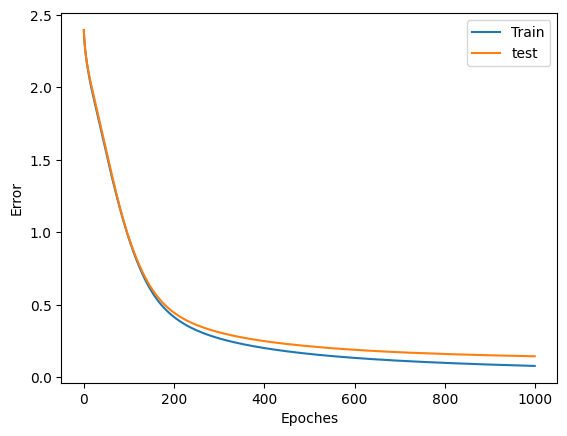

In [4]:
#前のセルでlog_loss_trainとlog_loss_testに誤差が入っている
plt.plot(range(len(log_loss_train)),log_loss_train,label="Train")
plt.plot(range(len(log_loss_test)),log_loss_test,label="test")

#出力の方法設定(線の説明位置の設定)
plt.legend()
#X座標
plt.xlabel("Epoches")
#y座標
plt.ylabel("Error")
plt.show()


## 正解率

In [6]:
#現時点での学習パラーメータを使って
#x_testを入れて結果y_testを作る
#x_testはたくさんあるので、それぞれに合わせて
#結果がでる。y_testもたくさんある
y_test = net(x_test)

#データの状況を出力(確認用)
print("ytest=", len(y_test))
print("ttest=", len(t_test))
print("ytest=", y_test[0])
print("ttest=", t_test[0])

#softmaxの処理をさぼってますね。
#この教科書

count=0

#テストのデータ個数分正解かチェック
for i in range(len(y_test)):
  #testの予測y_testの0～9までの確率のうち
  #最大となる整数を出力としてy_labelにする
  #t_testはもとから設定されている正解ラベル
  y_label=y_test[i].argmax().item()
  t_label=t_test[i].item()

  #予測と正解ラベルが尾内だったらカウントアップ
  if y_label==t_label:
    count+=1

cr = count/len(y_test)
print("正解率:", cr)

ytest= 450
ttest= 450
ytest= tensor([-8.8415,  0.2238, -7.2599, -1.4980, -2.7050, 10.2588, -5.4896,  1.3566,
        -0.0959,  4.2066], grad_fn=<SelectBackward0>)
ttest= tensor(5)
正解率: 0.96


#課題3<br>
学習率lrを変更したときに損失をグラフにせよ。

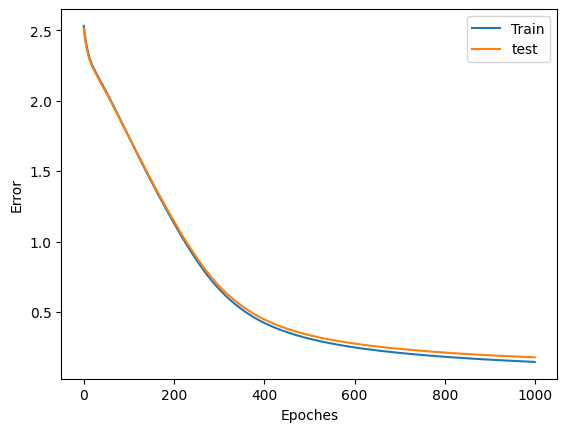

正解率 0.9511111111111111


In [46]:
from torch import nn
from torch import optim

#ニューラルネットワークの定義部
net = nn.Sequential(
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16,10)
 )
#print(net)

##学習の設定と学習の実行t_times回
t_times=1000


#損失にはクロスエントロピー誤差をつかう
loss_fnc=nn.CrossEntropyLoss()

#SGD（パラメータ最適化用)の設定
#学習率(learning rate lr=0.01)
optimizer = optim.SGD(net.parameters(), lr=0.005)

#損失をプロットするためのlog
log_loss_train=[]
log_loss_test=[]

for i in range(t_times):
  #パラメータの勾配を0に(初期設定)
  optimizer.zero_grad()

  #順伝搬で処理する(y=ＷX+bのようなもの)
  y_train = net(x_train)
  y_test = net(x_test)

  loss_train = loss_fnc(y_train, t_train)
  loss_test=loss_fnc(y_test, t_test)

  #.itemはテンソルなので１つめをとるのに
  log_loss_train.append(loss_train.item())
  log_loss_test.append(loss_test.item())

  #逆伝搬(最重要：学習の準備の設定　自動ですけどね)
  loss_train.backward()

  #パラーメータの更新(学習の実施)
  optimizer.step()

  #途中の学習状況の表示
  if i % 100 == 0:
    l1=loss_train.item()
    l2=loss_test.item()
#    print("Epoch:", i, "Loss_Train:",l1, "Loss_Test:", l2)


###見える化
plt.plot(range(len(log_loss_train)),log_loss_train,label="Train")
plt.plot(range(len(log_loss_test)),log_loss_test,label="test")


plt.legend()
#X座標
plt.xlabel("Epoches")
#y座標
plt.ylabel("Error")
plt.show()

####精度を出力
y_test = net(x_test)
count=0
for i in range(len(y_test)):
  y_label=y_test[i].argmax().item()
  t_label=t_test[i].item()

  if y_label ==t_label:
    count+=1
cr=count/len(y_test)
print("正解率", cr)


#課題4<br>
ニューラルネットワークのモデルの変更<br>
(64x32)→(32,16)→(16,10)がオリジナル<br>
(64x8)→(8,8)→(8,10)がオリジナル


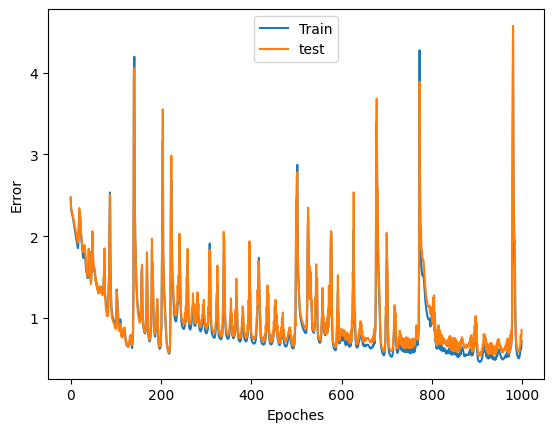

正解率 0.7511111111111111


In [85]:
from torch import nn
from torch import optim

#ニューラルネットワークの定義部
net = nn.Sequential(
    nn.Linear(64,8),
    nn.ReLU(),
    nn.Linear(8,8),
    nn.ReLU(),
    nn.Linear(8,10)
)
#print(net)

##学習の設定と学習の実行t_times回
t_times=1000


#損失にはクロスエントロピー誤差をつかう
loss_fnc=nn.CrossEntropyLoss()

#SGD（パラメータ最適化用)の設定
#学習率(learning rate lr=0.01)
optimizer = optim.SGD(net.parameters(), lr=0.1)

#損失をプロットするためのlog
log_loss_train=[]
log_loss_test=[]

for i in range(t_times):
  #パラメータの勾配を0に(初期設定)
  optimizer.zero_grad()

  #順伝搬で処理する(y=ＷX+bのようなもの)
  y_train = net(x_train)
  y_test = net(x_test)

  loss_train = loss_fnc(y_train, t_train)
  loss_test=loss_fnc(y_test, t_test)

  #.itemはテンソルなので１つめをとるのに
  log_loss_train.append(loss_train.item())
  log_loss_test.append(loss_test.item())

  #逆伝搬(最重要：学習の準備の設定　自動ですけどね)
  loss_train.backward()

  #パラーメータの更新(学習の実施)
  optimizer.step()

  #途中の学習状況の表示
  if i % 100 == 0:
    l1=loss_train.item()
    l2=loss_test.item()
#    print("Epoch:", i, "Loss_Train:",l1, "Loss_Test:", l2)


###見える化
plt.plot(range(len(log_loss_train)),log_loss_train,label="Train")
plt.plot(range(len(log_loss_test)),log_loss_test,label="test")


plt.legend()
#X座標
plt.xlabel("Epoches")
#y座標
plt.ylabel("Error")
plt.show()

####精度を出力
y_test = net(x_test)
count=0
for i in range(len(y_test)):
  y_label=y_test[i].argmax().item()
  t_label=t_test[i].item()

  if y_label ==t_label:
    count+=1
cr=count/len(y_test)
print("正解率", cr)


#課題5<br>
ニューラルネットワークのモデル層の変更

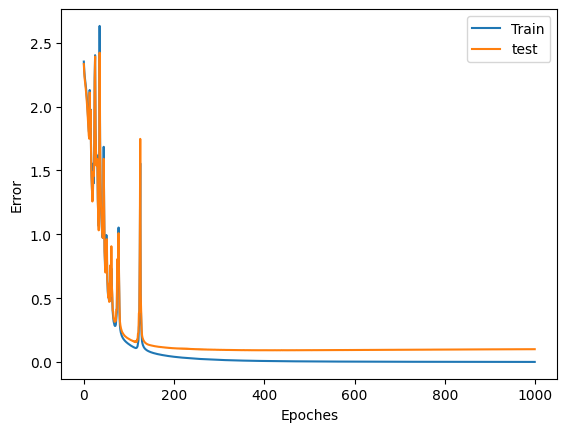

正解率 0.98


In [67]:
from torch import nn
from torch import optim

#ニューラルネットワークの定義部
net = nn.Sequential(
    nn.Linear(64,30),
    nn.ReLU(),
    nn.Linear(30,20),
    nn.ReLU(),
    nn.Linear(20,20),
    nn.ReLU(),
    nn.Linear(20,10)
)
#print(net)

##学習の設定と学習の実行t_times回
t_times=1000


#損失にはクロスエントロピー誤差をつかう
loss_fnc=nn.CrossEntropyLoss()

#SGD（パラメータ最適化用)の設定
#学習率(learning rate lr=0.01)
optimizer = optim.SGD(net.parameters(), lr=0.1)

#損失をプロットするためのlog
log_loss_train=[]
log_loss_test=[]

for i in range(t_times):
  #パラメータの勾配を0に(初期設定)
  optimizer.zero_grad()

  #順伝搬で処理する(y=ＷX+bのようなもの)
  y_train = net(x_train)
  y_test = net(x_test)

  loss_train = loss_fnc(y_train, t_train)
  loss_test=loss_fnc(y_test, t_test)

  #.itemはテンソルなので１つめをとるのに
  log_loss_train.append(loss_train.item())
  log_loss_test.append(loss_test.item())

  #逆伝搬(最重要：学習の準備の設定　自動ですけどね)
  loss_train.backward()

  #パラーメータの更新(学習の実施)
  optimizer.step()

  #途中の学習状況の表示
  if i % 100 == 0:
    l1=loss_train.item()
    l2=loss_test.item()
#    print("Epoch:", i, "Loss_Train:",l1, "Loss_Test:", l2)


###見える化
plt.plot(range(len(log_loss_train)),log_loss_train,label="Train")
plt.plot(range(len(log_loss_test)),log_loss_test,label="test")


plt.legend()
#X座標
plt.xlabel("Epoches")
#y座標
plt.ylabel("Error")
plt.show()

####精度を出力
y_test = net(x_test)
count=0
for i in range(len(y_test)):
  y_label=y_test[i].argmax().item()
  t_label=t_test[i].item()

  if y_label ==t_label:
    count+=1
cr=count/len(y_test)
print("正解率", cr)


# 課題6<br>
閾値関数をReLUから変更した場合<br>
(64x8)→(8,8)→(8,10)の3層モデルに対して<br>
活性化関数を変更<br>
①Sigmoid関数
②GELU関数

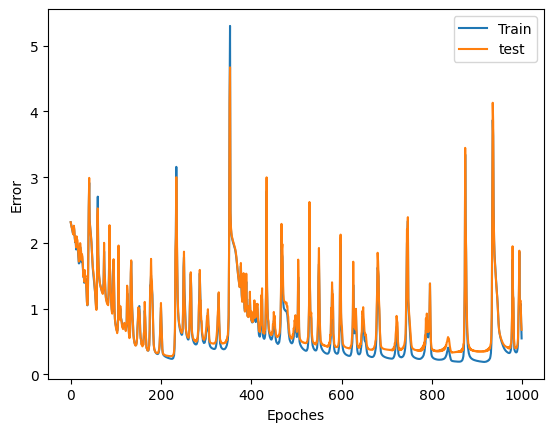

正解率 0.8822222222222222


In [84]:
from torch import nn
from torch import optim

#ニューラルネットワークの定義部
net = nn.Sequential(
    nn.Linear(64,8),
    nn.GELU(),
    nn.Linear(8,8),
    nn.GELU(),
    nn.Linear(8,10)
)
#print(net)

##学習の設定と学習の実行t_times回
t_times=1000


#損失にはクロスエントロピー誤差をつかう
loss_fnc=nn.CrossEntropyLoss()

#SGD（パラメータ最適化用)の設定
#学習率(learning rate lr=0.01)
optimizer = optim.SGD(net.parameters(), lr=0.1)

#損失をプロットするためのlog
log_loss_train=[]
log_loss_test=[]

for i in range(t_times):
  #パラメータの勾配を0に(初期設定)
  optimizer.zero_grad()

  #順伝搬で処理する(y=ＷX+bのようなもの)
  y_train = net(x_train)
  y_test = net(x_test)

  loss_train = loss_fnc(y_train, t_train)
  loss_test=loss_fnc(y_test, t_test)

  #.itemはテンソルなので１つめをとるのに
  log_loss_train.append(loss_train.item())
  log_loss_test.append(loss_test.item())

  #逆伝搬(最重要：学習の準備の設定　自動ですけどね)
  loss_train.backward()

  #パラーメータの更新(学習の実施)
  optimizer.step()

  #途中の学習状況の表示
  if i % 100 == 0:
    l1=loss_train.item()
    l2=loss_test.item()
#    print("Epoch:", i, "Loss_Train:",l1, "Loss_Test:", l2)


###見える化
plt.plot(range(len(log_loss_train)),log_loss_train,label="Train")
plt.plot(range(len(log_loss_test)),log_loss_test,label="test")


plt.legend()
#X座標
plt.xlabel("Epoches")
#y座標
plt.ylabel("Error")
plt.show()

####精度を出力
y_test = net(x_test)
count=0
for i in range(len(y_test)):
  y_label=y_test[i].argmax().item()
  t_label=t_test[i].item()

  if y_label ==t_label:
    count+=1
cr=count/len(y_test)
print("正解率", cr)
